# Catching Phishing URLs with Logistic Regression
**MLDS × ISACA**

You'll build a model that looks at a URL and estimates the probability that it's a phishing link.


--- 
**How this notebook works**

Cells are marked with these emojis.
- ✏️: Yours to write. The instructions above each one tell you what to do and what to name things so that later cells work.
- 🆘: Only run them if you're stuck. They'll get you to the next section.
- 💬: Stop and think, or talk to the people next to you. Answers can go in the markdown cell below the stop and think cell.


---

## 0. Setup
Run this cell

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_colwidth', None)

FILE_PATH = 'phishing_urls.csv'

---

## 1. Load the data
Our data is a sample of the **PhiUSIIL** phishing URL dataset. It has two columns:
- `URL`: the link
- `label`: **1 = phishing**, **0 = legitimate**

✏️ Load the data into a DataFrame called `df` with `pd.read_csv()`, passing it `DATA_URL`. Then check how many rows and columns it has (`.shape`) and look at the first few rows (`.head()`).

In [9]:
df = pd.read_csv(FILE_PATH)
print(df.shape)
df.head()

(20000, 2)


,URL,label
0,http://www.cxgglm.com,1
1,http://www.milhojas.is,1
2,https://www.cradlcase.com,0
3,https://www.openwga.com,0
4,https://www.micheleaikin.com,0


---

## 2. Inspect the data

### Class balance
Before modeling, we want to know how many of each class we have. If 99% of URLs were legitimate, a "model" that always says *legit* would be 99% accurate and completely useless.

✏️ Use `.value_counts()` on the `label` column. Then run it again with `normalize=True` to see proportions.

In [3]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

label
0    11415
1     8585
Name: count, dtype: int64
label
0    0.57075
1    0.42925
Name: proportion, dtype: float64


💬 Is this balanced enough that accuracy is a fair first metric? What accuracy would you get by always guessing the bigger class?

*Your answer:*

### Read some URLs
✏️ Print 10 random **phishing** URLs and 10 random **legitimate** URLs.

*Hint:* filter first, then sample. `df[df['label'] == 1]['URL'].sample(10)`

In [4]:
df[df['label'] == 1]['URL'].sample(10, random_state=1)

7656                                                                                                                                                                                                                                                                        http://www.ws025.hemnes.win
7348     https://bikanertahlka.com/wp-content/uploads/2023/index1.php?213857b81c358127342469ff43040d84213857b81c358127342469ff43040d84213857b81c358127342469ff43040d84213857b81c358127342469ff43040d84213857b81c358127342469ff43040d84213857b81c358127342469ff43040d84213857b81c358127342469ff43040d84=
13457                                                                                                                                                                                                                                              https://habilitarcuentaebisa.avisodebloqueo.repl.co/
16453                                                                                                           

In [5]:
df[df['label'] == 0]['URL'].sample(10, random_state=1)

11977          https://www.zinctextile.com
2266            https://www.bookbasset.com
17761       https://www.biancajewelers.com
15188           https://www.remobjects.com
5210      https://www.jacksoncountysoe.org
6738            https://www.ece.gatech.edu
3847          https://www.pref.nagasaki.jp
8166          https://www.blog.lenodal.com
17104            https://www.shaligram.com
1098     https://www.ainirentalmobil.my.id
Name: URL, dtype: str

💬 What do you notice? Which of the red flags that we talked about can you actually spot? Can you spot anything that we didn't discuss?

*Your answer:*

---

## 3. Turn red flags into features
A model can't read a URL. It needs **numbers**. A *feature* is one number we compute from every URL, like its length or whether it contains `@`. Each feature becomes one column.

pandas has string methods that run on a whole column at once through `.str`:
```python
df['URL'].str.len()            # length of every URL
df['URL'].str.count('-')       # number of dashes in every URL
df['URL'].str.contains('@')    # True/False for every URL
```

We'll put all our features inside **one function**, `make_features`. It takes a column of URLs and returns a table of features. Writing it as a function means we can run brand-new URLs through it at the end.

Some red flags only make sense for the **domain** (the `www.example.com` part), so the function also pulls that out as `host`.

### Feature menu

| Red flag (slide 3) | Feature name | What it measures | Hint |
|---|---|---|---|
| Long, cluttered URL | `url_length` | Total characters in the URL | `.str.len()` |
| Long, cluttered URL | `num_digits` | How many digits appear anywhere in the URL | `.str.count(r'\d')` |
| Long, cluttered URL | `num_special` | Count of `?`, `=`, and `&` (query-string clutter) | `.str.count(r'[?=&]')` |
| Long, cluttered URL | `num_hyphens` | Dashes, common in fake domains like `account-verify` | `.str.count('-')` |
| "@" trick | `has_at` | 1 if the URL contains `@`, else 0 | `.str.contains('@').astype(int)` |
| IP address instead of a name | `has_ip` | 1 if the domain is a raw IP address | use `host`: `.str.contains(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}').astype(int)` |
| Real brand buried in a subdomain | `num_subdomains` | Dots in the domain; more dots = more stacked subdomains | use `host`: `.str.count(r'\.')` |
| Lookalike domain | `host_digits` | Digits in the domain (`paypa1`, `micr0soft`) | use `host`: `.str.count(r'\d')` |
| Unusual top-level domain | `suspicious_tld` | 1 if the domain ends in a sketchy TLD | use `host`: `.str.endswith(('.xyz', '.top', '.zip')).astype(int)` |
| *(bonus)* Not encrypted | `is_https` | 1 if the URL starts with `https` | `.str.startswith('https').astype(int)` |

**You don't need all of these.**

💬 **Before you write any code:** which **2** features do you think will be the strongest signal? Write your guess down. We'll check it in section 6.

*My guess:*

✏️ Add **at least 3** features to `make_features`, following the `url_length` example. Each one goes in as a new column of `out`. Use `urls` for whole-URL features and `host` for domain-only features.

In [10]:
def make_features(urls):
    out = pd.DataFrame(index=urls.index)
    urls = urls.str.replace(r'://www\.', '://', regex=True)   # drop 'www.' (it's just formatting)
    host = urls.str.split('/').str[2].fillna('')              # the domain, e.g. 'paypal.com'

    out['url_length'] = urls.str.len()                        # worked example

    out['num_digits']     = urls.str.count(r'\d')
    out['num_special']    = urls.str.count(r'[?=&]')
    out['num_hyphens']    = urls.str.count('-')
    out['has_at']         = urls.str.contains('@').astype(int)
    out['has_ip']         = host.str.contains(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}').astype(int)
    out['num_subdomains'] = host.str.count(r'\.')
    out['host_digits']    = host.str.count(r'\d')
    out['suspicious_tld'] = host.str.endswith(('.xyz', '.top', '.zip')).astype(int)
    out['is_https']       = urls.str.startswith('https').astype(int)

    return out

Now run your function on every URL. The result is our feature table, `X`.

In [11]:
X = make_features(df['URL'])
y = df['label']
X.head()

,url_length,num_digits,num_special,num_hyphens,has_at,has_ip,num_subdomains,host_digits,suspicious_tld,is_https
0,17,0,0,0,0,0,1,0,0,0
1,18,0,0,0,0,0,1,0,0,0
2,21,0,0,0,0,0,1,0,0,1
3,19,0,0,0,0,0,1,0,0,1
4,24,0,0,0,0,0,1,0,0,1


### Check
A feature that is almost always 0 doesn't give the model much to learn from. Run this to see how often each feature is non-zero.

In [12]:
(X > 0).mean().sort_values()

has_ip            0.00290
has_at            0.00680
suspicious_tld    0.01720
num_special       0.02635
host_digits       0.16715
num_hyphens       0.19600
num_digits        0.21760
is_https          0.77995
url_length        1.00000
num_subdomains    1.00000
dtype: float64

💬 Are any of your features almost never non-zero? Would you keep them? 

---

## 4. Do the features actually differ between classes?
✏️ Compare the **average** of each feature for phishing vs. legitimate URLs.

**Hint**: Think about using `groupby()` with `y`, followed by `.mean()`. Check the orientation of your resulting DataFrame: `.T` might make the comparison easier to read.

In [18]:
X.groupby(y).mean().T

label,0,1
url_length,23.284275,44.957833
num_digits,0.046255,4.553058
num_special,0.000000,0.309027
num_hyphens,0.084538,0.732324
has_at,0.000000,0.015842
has_ip,0.000000,0.006756
num_subdomains,1.169864,1.761211
host_digits,0.046255,1.979266
suspicious_tld,0.000175,0.039837
is_https,1.000000,0.487362


✏️ Make a boxplot of `url_length` for each class.

*Hint:* first join the label back on with `X.assign(label=y)`, then use `.boxplot(column='url_length', by='label', showfliers=False)`.

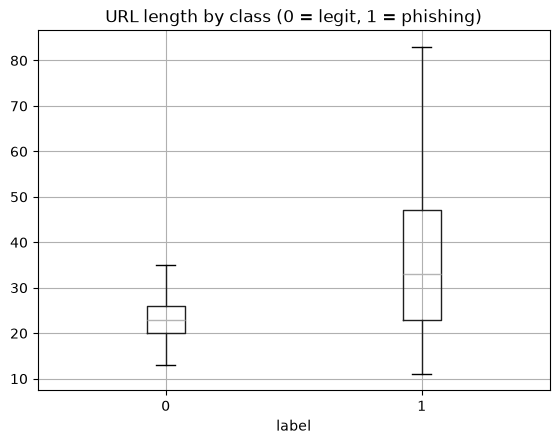

In [14]:
X.assign(label=y).boxplot(column='url_length', by='label', showfliers=False)
plt.title('URL length by class (0 = legit, 1 = phishing)')
plt.suptitle('')
plt.show()

💬 Which features look the most different between the two classes? Does that match your guess?

*Your answer:*

---

## 5. Train the model

### Split
We train on one part of the data and test on URLs the model has **never seen**, just like a real detector meeting a brand-new phishing site.

✏️ Use `train_test_split` to make `X_train, X_test, y_train, y_test`. Use `test_size=0.2`, `random_state=42`, and `stratify=y` (this keeps the phishing/legit ratio the same in both parts).

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(16000, 10) (4000, 10)


### Scale
`url_length` might be 80 while `has_at` is 0 or 1. If we leave them like that, the weights aren't comparable, so we couldn't say which feature matters most. `StandardScaler` puts every feature on the same scale (mean 0, standard deviation 1).

Note that we **fit** the scaler on the training data only, then apply it to both. The test set has to stay unseen.

In [32]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

### Fit
✏️ Create a `LogisticRegression()` called `model` and `.fit()` it on `X_train_s` and `y_train`.

In [33]:
model = LogisticRegression()
model.fit(X_train_s, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

---

## 6. Read the weights
Remember from the slides: **z = w₁x₁ + w₂x₂ + … + b**. A big **positive** weight pushes a URL toward *phishing*, and a big **negative** weight pushes it toward *legit*.

In [34]:
weights = pd.Series(model.coef_[0], index=X.columns).sort_values()
weights

is_https         -4.553172
has_ip           -0.025266
has_at            0.342554
num_subdomains    0.793268
suspicious_tld    0.812864
num_hyphens       1.359877
host_digits       1.852100
num_special       1.897464
num_digits        7.292722
url_length        9.848916
dtype: float64

✏️ Make a horizontal bar chart of `weights`. *Hint:* `.plot(kind='barh')`

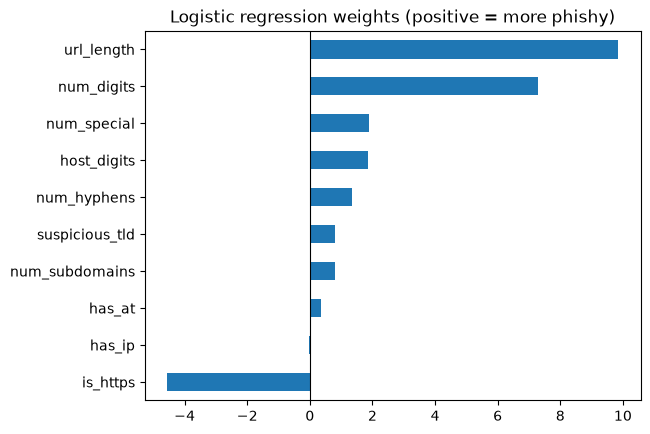

In [35]:
weights.plot(kind='barh')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic regression weights (positive = more phishy)')
plt.show()

💬 Which feature has the biggest positive weight? The biggest negative one? Do they match your guess and ISACA's red flags? Any surprises?

*Your answer:*

---

## 7. How good is it?

### Accuracy vs. a dumb baseline
✏️ Make predictions on the test set and call them `y_pred`. Then compute `accuracy_score(y_test, y_pred)`.

Compare that to the **baseline**: the accuracy you'd get by always guessing the bigger class.

In [36]:
y_pred = model.predict(X_test_s)
print('Model accuracy:   ', round(accuracy_score(y_test, y_pred), 3))

baseline = y_test.value_counts(normalize=True).max()
print('Baseline accuracy:', round(baseline, 3))

Model accuracy:    0.958
Baseline accuracy: 0.571


### Confusion matrix
Rows show what the URL **really** is, and columns show what the model **said**.

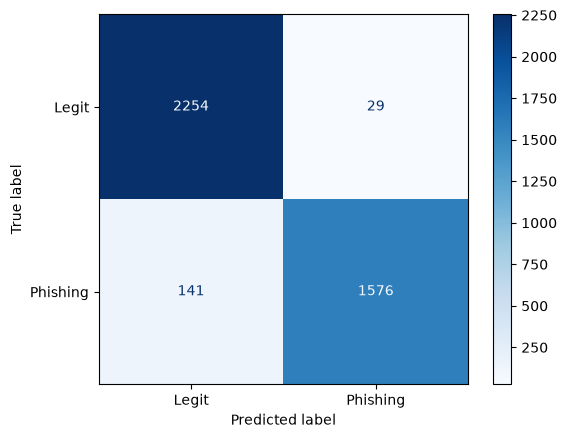

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=['Legit', 'Phishing'], cmap='Blues'
)
plt.show()

### Precision and recall
- **Recall**: of all the phishing URLs, how many did we catch?
- **Precision**: of the URLs we flagged, how many were really phishing?

✏️ Compute both with `precision_score(y_test, y_pred)` and `recall_score(y_test, y_pred)`.

In [38]:
print('Precision:', round(precision_score(y_test, y_pred), 3))
print('Recall:   ', round(recall_score(y_test, y_pred), 3))

Precision: 0.982
Recall:    0.918


💬 Which mistake is worse here: a missed phishing link (false negative) or a false alarm (false positive)? Which box in the confusion matrix is that?

*Your answer:*

---

## 8. Move the threshold
`model.predict` calls anything with P(phishing) > 0.5 phishing. That 0.5 is a choice, not a law.

`predict_proba` gives us the actual probabilities, so we can pick our own cutoff.

In [39]:
probs = model.predict_proba(X_test_s)[:, 1]   # P(phishing) for each test URL
probs[:10].round(3)

array([0.02 , 0.016, 0.011, 0.339, 0.036, 0.044, 1.   , 0.054, 1.   ,
       0.004])

✏️ Fill in the loop: for each threshold, turn `probs` into 0/1 predictions (`probs >= t`), then compute precision and recall.

In [40]:
rows = []
for t in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds_t = (probs >= t).astype(int)
    rows.append({
        'threshold': t,
        'precision': precision_score(y_test, preds_t, zero_division=0),
        'recall':    recall_score(y_test, preds_t),
    })

pd.DataFrame(rows).round(3)

,threshold,precision,recall
0,0.2,0.921,0.951
1,0.3,0.958,0.937
2,0.4,0.968,0.925
3,0.5,0.982,0.918
4,0.6,0.987,0.910
5,0.7,0.993,0.894
6,0.8,0.997,0.878


💬 If you ran the security team, where would you set the threshold? What would you be trading away?

*Your answer:*

---

## 9. What did it miss?
These are phishing URLs that the model called **safe** (false negatives).

In [41]:
test_results = pd.DataFrame({
    'URL': df.loc[X_test.index, 'URL'],
    'actual': y_test,
    'predicted': y_pred,
    'p_phishing': probs.round(3),
})

missed = test_results[(test_results['actual'] == 1) & (test_results['predicted'] == 0)]
print(len(missed), 'phishing URLs missed')
missed.sample(min(10, len(missed)), random_state=0)

141 phishing URLs missed


,URL,actual,predicted,p_phishing
17267,https://fisdiu.vip/,1,0,0.011
17750,https://rezemebremes.web.app/,1,0,0.216
14383,https://zkdrop.info/,1,0,0.013
9035,https://www.nutcrackersweet.com/rfnd.php,1,0,0.268
4604,https://zermebremere.web.app/,1,0,0.216
17585,https://www.1lnch.me/index.html,1,0,0.147
3886,https://lindencroft.com/a/berlann3,1,0,0.272
14257,https://pomadorepoms.com/index.php,1,0,0.195
18908,https://www.serviziofatturazione-pec.com/,1,0,0.446
846,https://sqd5vibfv.web.app/,1,0,0.310


💬 What do the missed ones have in common? Which red flag would have caught them, if any?

*Your answer:*

### 🏆 Challenge: fool the model
✏️ Write URLs that a person would flag as phishing but the model thinks are safe. Add them to the list and run the cell. Can you get one under 0.5?

In [42]:
my_urls = pd.Series([
    'https://www.paypal.com',            # a real one, for comparison
    'https://paypa1.com/login',
    'http://203.0.113.42/paypal-login',
    'https://secure-paypal.com/verify',
])

my_probs = model.predict_proba(scaler.transform(make_features(my_urls)))[:, 1]
pd.DataFrame({'URL': my_urls, 'p_phishing': my_probs.round(3)})

,URL,p_phishing
0,https://www.paypal.com,0.009
1,https://paypa1.com/login,0.085
2,http://203.0.113.42/paypal-login,1.000
3,https://secure-paypal.com/verify,0.223


---

## 10. Wrap-up
- A handful of string features plus logistic regression already gets a working detector, and you can **read** why it decides what it does.
- In real systems, this would be one layer: a **blocklist** first, a fast model like this one as a first pass, then heavier models (random forests, XGBoost, BERT-style models) on anything suspicious.
- Attackers adapt. Once they know which features get flagged, they avoid them, so real detectors are constantly retrained and combined with other signals.

💬 **If you had another hour,** what feature would you add next?